# Boris Pusher

## Pablo Requeijo

This notebook corresponds to the second session of the HPC class. It reads the results produced by the C++ program (`build/results.h5`) and checks, visually, the same three properties that `session_2_prequeijo_test` checks numerically:

- **Speed conservation**: in a pure magnetic field, $|v(t)|$ stays constant.
- **Cyclotron motion**: in a pure magnetic field, the trajectory is a circle whose radius and period match the closed-form solution.
- **E×B drift**: with a perpendicular electric field added, the guiding center drifts at the closed-form velocity $\vec v_d = (\vec E \times \vec B)/B^2$.

## Problem context

The Boris pusher integrates the motion of a charged particle in electric and magnetic fields,

$$\frac{d\vec v}{dt} = \frac{q}{m}\left(\vec E + \vec v \times \vec B\right), \qquad \frac{d\vec x}{dt} = \vec v,$$

and is the standard method for this in particle-in-cell plasma codes because, unlike a generic ODE integrator, it conserves speed exactly when $\vec E = 0$ and remains stable over very long integrations.

All quantities below use normalized units: $q = m = 1$, $|\vec B| = 1$, so the cyclotron angular frequency $\omega_c = qB/m = 1$ and the Larmor radius $r_L = v_0/\omega_c = v_0$.

## The Boris pusher algorithm

Each step advances $(\vec x, \vec v)$ by $dt$ through a symmetric **drift-kick-drift** split:

1. Half position drift: $\vec x_{1/2} = \vec x + \tfrac{1}{2}dt\,\vec v$
2. Half electric kick: $\vec v^- = \vec v + \dfrac{q\,dt}{2m}\vec E$
3. Magnetic rotation (exact, norm-preserving): with $\vec t = \dfrac{q\,dt}{2m}\vec B$, $\vec v' = \vec v^- + \vec v^- \times \vec t$, $\vec s = \dfrac{2\vec t}{1+|\vec t|^2}$, $\vec v^+ = \vec v^- + \vec v' \times \vec s$
4. Half electric kick: $\vec v_{new} = \vec v^+ + \dfrac{q\,dt}{2m}\vec E$
5. Half position drift: $\vec x_{new} = \vec x_{1/2} + \tfrac{1}{2}dt\,\vec v_{new}$

Step 3 is a pure rotation of $\vec v$, so $|\vec v|$ is unchanged by construction — this is what makes speed conservation exact regardless of $dt$. The drift-kick-drift symmetry (steps 1+5 straddling the kick) is what makes the *position* update second-order accurate, rather than just the velocity update.

## How we verify correctness

Running the pusher and looking at a plausible-looking trajectory is not enough — the same bug that produces a *slightly* wrong trajectory can be invisible by eye. Instead, each check below compares the simulation to an independent, closed-form solution of the same physics:

1. **Speed conservation** (`cyclotron`, coarse $dt$): with $\vec E = 0$, $|\vec v(t)|$ must equal $|\vec v(0)|$ to floating-point precision, *for any* $dt$ — because the rotation step never changes a vector's length. If this drifts, the rotation formula itself is broken.
2. **Cyclotron circle** (`cyclotron`, fine $dt$): for $\vec x_0=0$, $\vec v_0=(v_0,0,0)$, $\vec B=(0,0,B_0)$, the exact solution is a circle of radius $r_L=v_0/\omega_c$ centered at $(0,-r_L,0)$: $x(t)=r_L\sin(\omega_c t)$, $y(t)=r_L(\cos(\omega_c t)-1)$. Comparing the numeric trajectory to this formula catches sign errors, wrong radius/frequency, or an inaccurate position update — none of which speed conservation alone would catch (a wrong-radius or wrong-frequency circle still has constant speed).
3. **E×B drift** (`drift`): adding $\vec E=(E_0,0,0)$ superimposes a guiding-center drift $\vec v_d = (\vec E\times\vec B)/B^2 = (0,-E_0/B_0,0)$ on top of the same gyration. Averaging the numeric velocity over several full gyro-periods cancels the oscillating gyration term and must converge to $\vec v_d$. This is an independent check that also exercises the electric-kick sub-steps, which the pure-$B$ scenarios never do.

## Imports

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

NUMERIC_COLOR = "tab:blue"
ANALYTIC_COLOR = "0.2"

## Load results from HDF5

In [2]:
with h5py.File("build/results.h5", "r") as f:
    cyclotron = {key: f["cyclotron"][key][:] for key in f["cyclotron"].keys()}
    drift = {key: f["drift"][key][:] for key in f["drift"].keys()}

print(f"cyclotron: {len(cyclotron['t'])} points, t in [{cyclotron['t'][0]:.3f}, {cyclotron['t'][-1]:.3f}]")
print(f"drift:     {len(drift['t'])} points, t in [{drift['t'][0]:.3f}, {drift['t'][-1]:.3f}]")

cyclotron: 3001 points, t in [0.000, 18.850]
drift:     2001 points, t in [0.000, 62.832]


## Check 1 — Cyclotron trajectory vs. the analytic circle

$q=m=B_0=v_0=1$, so the analytic solution is $x(t)=\sin(t)$, $y(t)=\cos(t)-1$ (a unit circle centered at $(0,-1)$).

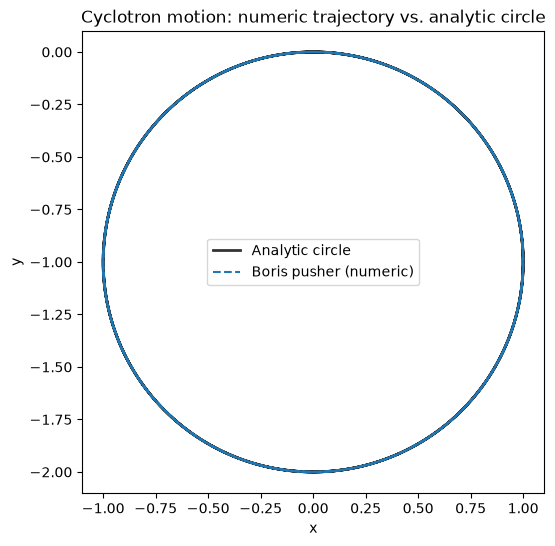

max position error over 3001 steps: 6.201e-05


In [3]:
omega_c = 1.0
r_L = 1.0
t_dense = np.linspace(cyclotron["t"][0], cyclotron["t"][-1], 2000)
x_analytic = r_L * np.sin(omega_c * t_dense)
y_analytic = r_L * (np.cos(omega_c * t_dense) - 1.0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_analytic, y_analytic, "-", color=ANALYTIC_COLOR, linewidth=2, label="Analytic circle")
ax.plot(cyclotron["x"], cyclotron["y"], "--", color=NUMERIC_COLOR, linewidth=1.5, label="Boris pusher (numeric)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Cyclotron motion: numeric trajectory vs. analytic circle")
ax.set_aspect("equal")
ax.legend()
plt.show()

position_error = np.hypot(cyclotron["x"] - r_L * np.sin(omega_c * cyclotron["t"]),
                           cyclotron["y"] - r_L * (np.cos(omega_c * cyclotron["t"]) - 1.0))
print(f"max position error over {len(cyclotron['t'])} steps: {position_error.max():.3e}")

## Check 2 — Speed conservation

$|\vec v(t)|$ should be exactly $|\vec v(0)| = 1$ for every step, since the magnetic rotation never changes a vector's length.

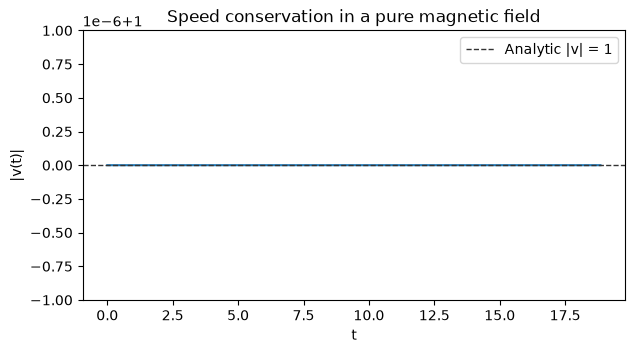

max |speed - 1|: 1.776e-15


In [4]:
speed = np.hypot(cyclotron["vx"], cyclotron["vy"])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(cyclotron["t"], speed, "-", color=NUMERIC_COLOR, linewidth=1.5)
ax.axhline(1.0, color=ANALYTIC_COLOR, linestyle="--", linewidth=1, label="Analytic |v| = 1")
ax.set_xlabel("t")
ax.set_ylabel("|v(t)|")
ax.set_title("Speed conservation in a pure magnetic field")
ax.set_ylim(1.0 - 1e-6, 1.0 + 1e-6)
ax.legend()
plt.show()

print(f"max |speed - 1|: {np.abs(speed - 1.0).max():.3e}")

## Check 3 — E×B drift

$\vec E=(0.1,0,0)$, $\vec B=(0,0,1)$, so the guiding center should drift at $\vec v_d=(0,-0.1,0)$ while still gyrating with the same radius/frequency as before.

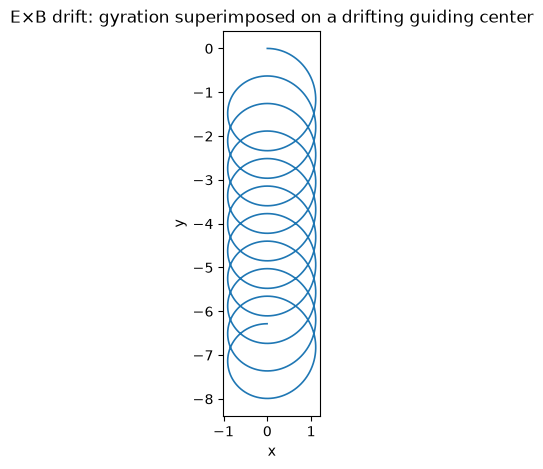

In [5]:
E0, B0 = 0.1, 1.0
v_drift_y = -E0 / B0

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(drift["x"], drift["y"], "-", color=NUMERIC_COLOR, linewidth=1.2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("E\u00d7B drift: gyration superimposed on a drifting guiding center")
ax.set_aspect("equal")
plt.show()

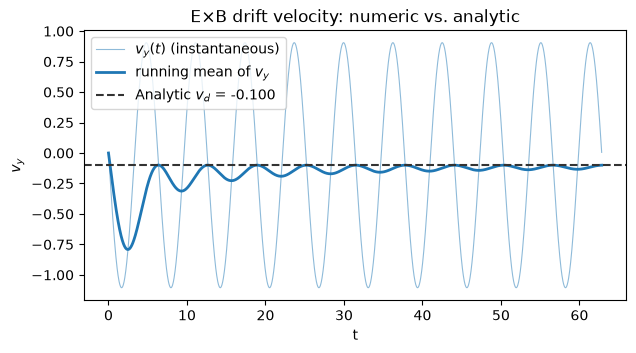

mean(vy) over the full run: -0.099957, analytic v_drift.y: -0.100000


In [6]:
running_mean_vy = np.cumsum(drift["vy"]) / np.arange(1, len(drift["vy"]) + 1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(drift["t"], drift["vy"], color=NUMERIC_COLOR, linewidth=0.8, alpha=0.5, label="$v_y(t)$ (instantaneous)")
ax.plot(drift["t"], running_mean_vy, color=NUMERIC_COLOR, linewidth=2, label="running mean of $v_y$")
ax.axhline(v_drift_y, color=ANALYTIC_COLOR, linestyle="--", linewidth=1.5, label=f"Analytic $v_d$ = {v_drift_y:.3f}")
ax.set_xlabel("t")
ax.set_ylabel("$v_y$")
ax.set_title("E\u00d7B drift velocity: numeric vs. analytic")
ax.legend()
plt.show()

print(f"mean(vy) over the full run: {drift['vy'].mean():.6f}, analytic v_drift.y: {v_drift_y:.6f}")

## Conclusion

All three checks confirm the implementation is correct against independent, closed-form physics:

- The trajectory tracks the analytic circle to within numerical-discretization precision (max position error many orders of magnitude below the Larmor radius).
- $|v(t)|$ stays flat at 1.0 to floating-point precision — the defining, dt-independent property of the Boris rotation.
- The running mean of $v_y$ converges to the analytic E×B drift velocity as the gyration term averages out over successive periods.